# Laboratorio Semana 4: Seq2Seq Ingles-Espanol desde cero

**Curso:** Deep Learning  
**Valor:** 4% de la nota del curso  
**Entrega:** Notebook ejecutado (.ipynb) con todas las celdas con salida visible

---

## Contexto

Esta semana implementa un modelo Seq2Seq completo para traduccion ingles-espanol con traducciones **naturales en espanol**: el corpus tiene deliberadamente oraciones donde el espanol es mas corto (por elision del sujeto: *she sings well* -> *canta bien*), mas largo (por perifrasis verbales: *the cat sleeps* -> *el gato esta durmiendo*), o del mismo largo. Esa asimetria de largo es exactamente la razon de ser de la arquitectura Encoder-Decoder.

Pipeline:
```
oracion_EN -> [E_enc] -> [Encoder LSTM] -> c = h_T^enc
                                            |
<SOS>+oracion_ES -> [E_dec] -> [Decoder LSTM] -> [W_out+softmax] -> prediccion
```

## Reglas

- Use unicamente PyTorch. No use `nn.LSTM`, `nn.Embedding`, `nn.Linear` ni capas de alto nivel.
- El backward debe ser **manual**. No use `loss.backward()`.
- No modifique los pesos iniciales ni el corpus.
- La celda final calcula su nota automatica sobre los **60 puntos** de codigo.

In [1]:
import torch
import torch.nn.functional as F
import hashlib, numpy as np, random, time
from collections import Counter
import matplotlib.pyplot as plt

def _hash_tensor(t, decimals=5):
    arr = np.round(t.detach().numpy().astype(np.float64), decimals)
    return hashlib.sha256(arr.tobytes()).hexdigest()

_resultados = {}
print(f'PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cpu


---
## Bloque 0: Corpus, vocabularios y pesos iniciales (dado, no modificar)

In [2]:
CORPUS_COMPLETO = [
    ("i love you", "te amo"),
    ("i drink water", "bebo agua"),
    ("i read the news", "leo las noticias"),
    ("i write a book", "escribo un libro"),
    ("i hear music", "escucho musica"),
    ("i call my mother", "llamo a mi madre"),
    ("i take a photo", "tomo una foto"),
    ("i finish my work", "termino mi trabajo"),
    ("i open the book", "abro el libro"),
    ("i run every morning", "corro cada manana"),
    ("i learn spanish", "aprendo espanol"),
    ("i like coffee", "me gusta el cafe"),
    ("i work every day", "trabajo todos los dias"),
    ("i buy fresh bread", "compro pan fresco"),
    ("she reads books", "lee libros"),
    ("she sings well", "canta bien"),
    ("she cooks dinner", "cocina la cena"),
    ("she opens the door", "abre la puerta"),
    ("she sleeps early", "duerme temprano"),
    ("she buys flowers", "compra flores"),
    ("she draws pictures", "dibuja imagenes"),
    ("she visits her friend", "visita a su amiga"),
    ("she teaches math", "ensena matematica"),
    ("she paints a picture", "pinta un cuadro"),
    ("she writes a poem", "escribe un poema"),
    ("she enjoys the music", "disfruta la musica"),
    ("she prepares the meal", "prepara la comida"),
    ("he runs fast", "corre rapido"),
    ("he writes a letter", "escribe una carta"),
    ("he closes the window", "cierra la ventana"),
    ("he eats an apple", "come una manzana"),
    ("he drives a car", "conduce un carro"),
    ("he fixes the bike", "arregla la bicicleta"),
    ("he plays the guitar", "toca la guitarra"),
    ("he studies history", "estudia historia"),
    ("he answers the phone", "contesta el telefono"),
    ("he repairs the chair", "repara la silla"),
    ("he teaches the class", "ensena la clase"),
    ("we eat bread", "comemos pan"),
    ("we walk together", "caminamos juntos"),
    ("we leave early", "salimos temprano"),
    ("we cook together", "cocinamos juntos"),
    ("we swim in the sea", "nadamos en el mar"),
    ("we watch the stars", "miramos las estrellas"),
    ("we visit the museum", "visitamos el museo"),
    ("we celebrate together", "celebramos juntos"),
    ("we enjoy the summer", "disfrutamos el verano"),
    ("they play soccer", "juegan futbol"),
    ("they arrive late", "llegan tarde"),
    ("they build a house", "construyen una casa"),
    ("they clean the room", "limpian el cuarto"),
    ("they watch the movie", "ven la pelicula"),
    ("they travel by train", "viajan en tren"),
    ("they eat together", "comen juntos"),
    ("they sing a song", "cantan una cancion"),
    ("they dance all night", "bailan toda la noche"),
    ("they plant the seeds", "plantan las semillas"),
    ("they clean the street", "limpian la calle"),
    ("the cat sleeps", "el gato esta durmiendo"),
    ("the dog barks", "el perro esta ladrando"),
    ("the bird flies", "el pajaro esta volando"),
    ("the sun shines", "el sol esta brillando"),
    ("the fish swims", "el pez esta nadando"),
    ("the baby laughs", "el bebe esta riendo"),
    ("the teacher explains", "el profesor esta explicando"),
    ("the rain falls", "la lluvia esta cayendo"),
    ("the moon rises", "la luna esta subiendo"),
    ("the wind blows", "el viento esta soplando"),
    ("the fire burns", "el fuego esta ardiendo"),
    ("the clock ticks", "el reloj esta sonando"),
    ("we study english", "estudiamos ingles"),
    ("we paint the wall", "pintamos la pared"),
    ("we drink hot tea", "bebemos te caliente"),
    ("we meet every week", "nos reunimos cada semana"),
    ("the cat drinks milk", "el gato bebe leche"),
    ("the child plays", "el nino juega"),
    ("he reads the newspaper", "lee el periodico"),
    ("she closes her eyes", "cierra los ojos"),
]

# Split 75/25 reproducible
random.seed(42)
indices = list(range(len(CORPUS_COMPLETO)))
random.shuffle(indices)
n_train = int(len(CORPUS_COMPLETO) * 0.75)
TRAIN_DATA = [CORPUS_COMPLETO[i] for i in indices[:n_train]]
TEST_DATA  = [CORPUS_COMPLETO[i] for i in indices[n_train:]]
print(f'Train: {len(TRAIN_DATA)} pares, Test: {len(TEST_DATA)} pares')
print(f'Primer par de entrenamiento: {TRAIN_DATA[0]}')
# Verificar distribucion de largos
diffs = [len(tgt.split())-len(src.split()) for src,tgt in CORPUS_COMPLETO]
from collections import Counter
print('Diferencia largo ES - largo EN:', dict(sorted(Counter(diffs).items())))


Train: 58 pares, Test: 20 pares
Primer par de entrenamiento: ('they play soccer', 'juegan futbol')
Diferencia largo ES - largo EN: {-1: 57, 0: 8, 1: 13}


In [3]:
SOS, EOS, PAD, UNK = '<SOS>', '<EOS>', '<PAD>', '<UNK>'
SPECIAL = [PAD, UNK, SOS, EOS]

def build_vocab(sentences):
    words = set()
    for s in sentences: words.update(s.lower().split())
    vocab = SPECIAL + sorted(words)
    w2i = {w: i for i, w in enumerate(vocab)}
    i2w = {i: w for w, i in w2i.items()}
    return vocab, w2i, i2w

src_vocab, src_w2i, src_i2w = build_vocab([p[0] for p in CORPUS_COMPLETO])
tgt_vocab, tgt_w2i, tgt_i2w = build_vocab([p[1] for p in CORPUS_COMPLETO])
src_V = len(src_vocab); tgt_V = len(tgt_vocab)
print(f'Vocabulario EN: {src_V} palabras')
print(f'Vocabulario ES: {tgt_V} palabras')

def tokenize_src(sentence):
    return [src_w2i.get(w.lower(), src_w2i[UNK]) for w in sentence.split()]

def tokenize_tgt(sentence):
    return ([tgt_w2i[SOS]] +
            [tgt_w2i.get(w.lower(), tgt_w2i[UNK]) for w in sentence.split()] +
            [tgt_w2i[EOS]])

Vocabulario EN: 158 palabras
Vocabulario ES: 163 palabras


In [4]:
d_emb = 16; d_hid = 32
torch.manual_seed(42)
E_enc = torch.randn(d_emb, src_V) * 0.1
E_dec = torch.randn(d_emb, tgt_V) * 0.1
Wf_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bf_enc=torch.zeros(d_hid)
Wi_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bi_enc=torch.zeros(d_hid)
Wc_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bc_enc=torch.zeros(d_hid)
Wo_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bo_enc=torch.zeros(d_hid)
Wf_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bf_dec=torch.zeros(d_hid)
Wi_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bi_dec=torch.zeros(d_hid)
Wc_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bc_dec=torch.zeros(d_hid)
Wo_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bo_dec=torch.zeros(d_hid)
W_out = torch.randn(tgt_V, d_hid) * 0.1; b_out = torch.zeros(tgt_V)
alpha = 0.01
print(f'E_enc: {E_enc.shape}, Wf_enc: {Wf_enc.shape}, W_out: {W_out.shape}')

E_enc: torch.Size([16, 158]), Wf_enc: torch.Size([32, 48]), W_out: torch.Size([163, 32])


---
## Bloque 1: Lookup de embeddings

Implemente `get_embedding` que selecciona la columna `idx` de la matriz `E`:

$$\mathbf{e} = E[:, \text{idx}]$$

El backward de esta operacion acumula gradiente **solo** en la columna `idx`: las palabras que no aparecen en la secuencia no reciben actualizacion.

Implemente tambien `get_embedding_batch` para una lista de indices.

In [5]:
def get_embedding(E, idx):
    """
    Se selecciona la columna idx de E. Retorna tensor (d_emb,).
    """
    return E[:, idx]

def get_embedding_batch(E, indices):
    """Se retorna lista de embeddings para una lista de indices."""
    return [E[:, idx] for idx in indices]

emb_test = get_embedding(E_enc, 0)
print(f'Embedding token 0: {emb_test.shape if emb_test is not None else None}')

Embedding token 0: torch.Size([16])


---
## Bloque 2: Celda LSTM y forward del encoder

Implemente `lstm_cell` con las cinco ecuaciones del LSTM.  
Luego implemente `encoder_forward` que lee la secuencia de entrada completa y retorna:
- `context_h`: hidden state final $h_T^{enc}$ (vector de contexto)
- `context_c`: cell state final $c_T^{enc}$
- `enc_caches`: lista de caches de cada paso (necesarios para el backward)

Guarde el indice del embedding en cada cache con la clave `'emb_idx'`.

**Importante:** el par de verificacion es `TRAIN_DATA[0] = ('they play soccer', 'juegan futbol')`. El encoder lee 3 tokens en ingles y el decoder genera 2 tokens en espanol mas EOS. Esta asimetria es intencional y debe funcionar sin cambios en el codigo.

In [6]:
def lstm_cell(h, c, x, Wf, bf, Wi, bi, Wc, bc, Wo, bo):
    """
    Un paso de tiempo LSTM.
    Retorna (h_new, c_new, cache).
    El cache debe contener: concat, h_prev, c_prev, f, i, ct, c_t, o, h_t
    """
    h_prev = h
    c_prev = c

    # Concatenar h y x -> vector de entrada combinado
    concat = torch.cat([h, x])                    # (d_hid + d_emb,)

    # 5 ecuaciones del LSTM
    f  = torch.sigmoid(Wf @ concat + bf)          # forget gate
    i  = torch.sigmoid(Wi @ concat + bi)          # input gate
    ct = torch.tanh(Wc @ concat + bc)             # candidate cell
    c_t = f * c_prev + i * ct                     # nuevo cell state
    o  = torch.sigmoid(Wo @ concat + bo)          # output gate
    h_t = o * torch.tanh(c_t)                     # nuevo hidden state

    cache = {
        'concat': concat,
        'h_prev': h_prev,
        'c_prev': c_prev,
        'f': f,
        'i': i,
        'ct': ct,
        'c_t': c_t,
        'o': o,
        'h_t': h_t,
    }
    return h_t, c_t, cache


def encoder_forward(src_indices, E_enc, Wf_enc, bf_enc, Wi_enc, bi_enc,
                    Wc_enc, bc_enc, Wo_enc, bo_enc):
    """
    Forward del encoder. Retorna (context_h, context_c, enc_caches).
    """
    h = torch.zeros(d_hid); c = torch.zeros(d_hid); caches = []

    for idx in src_indices:
        x = get_embedding(E_enc, idx)             # (d_emb,)
        h, c, cache = lstm_cell(h, c, x,
                                Wf_enc, bf_enc,
                                Wi_enc, bi_enc,
                                Wc_enc, bc_enc,
                                Wo_enc, bo_enc)
        cache['emb_idx'] = idx                    # guardamos el índice para el backward
        caches.append(cache)

    return h, c, caches


# Verificar con TRAIN_DATA[0]: 'they play soccer' -> 'juegan futbol'
src_test = tokenize_src(TRAIN_DATA[0][0])
context_h, context_c, enc_caches = encoder_forward(
    src_test, E_enc, Wf_enc, bf_enc, Wi_enc, bi_enc, Wc_enc, bc_enc, Wo_enc, bo_enc)
print(f'Entrada EN: {TRAIN_DATA[0][0]} -> tokens: {src_test}')
print(f'context_h forma: {context_h.shape if context_h is not None else None}')
print(f'Caches encoder: {len(enc_caches)} (uno por token de entrada)')

Entrada EN: they play soccer -> tokens: [138, 103, 122]
context_h forma: torch.Size([32])
Caches encoder: 3 (uno por token de entrada)


In [7]:
# VERIFICACION BLOQUE 2
_H = 'a1c22d089ecfb52bdae47e330603a46d492f9318dc6b2071956ef1a9c406eeec'
try:
    assert context_h is not None and context_h.shape == (d_hid,), \
        f'context_h debe ser ({d_hid},), obtenida {getattr(context_h,"shape",None)}'
    assert len(enc_caches) == len(src_test), \
        f'enc_caches debe tener {len(src_test)} entradas, tiene {len(enc_caches)}'
    assert _hash_tensor(context_h) == _H, 'context_h incorrecto.'
    _resultados['b2'] = True; print('BLOQUE 2: CORRECTO')
except AssertionError as e:
    _resultados['b2'] = False; print(f'BLOQUE 2: INCORRECTO\n  {e}')

BLOQUE 2: CORRECTO


---
## Bloque 3: Forward del decoder con teacher forcing

Implemente `decoder_forward` con teacher forcing.

El par de verificacion tiene **largo asimetrico**: el encoder leyo 3 tokens (*they play soccer*) y el decoder debe generar 2 tokens en espanol (*juegan futbol*) mas EOS. Su implementacion debe manejar cualquier combinacion de largos sin codigo especial.

- Input del decoder: `[SOS, juegan]` (largo 2)
- Target del decoder: `[juegan, futbol, EOS]` (largo 3)
- El decoder corre exactamente `len(dec_input_indices)` pasos

In [8]:
def decoder_forward(dec_input_indices, dec_target_indices, context_h, context_c,
                    E_dec, Wf_dec, bf_dec, Wi_dec, bi_dec,
                    Wc_dec, bc_dec, Wo_dec, bo_dec, W_out, b_out):
    """
    Forward decoder con teacher forcing.
    Retorna (logits_list, dec_caches)
    logits_list: lista de tensores (tgt_V,), uno por paso
    """
    h = context_h.clone(); c = context_c.clone()
    caches = []; logits_list = []

    # El decoder corre exactamente len(dec_input_indices) pasos
    for idx in dec_input_indices:
        # 1. Obtener embedding del token de entrada (teacher forcing)
        x = get_embedding(E_dec, idx)               # (d_emb,)

        # 2. Un paso LSTM del decoder
        h, c, cache = lstm_cell(h, c, x,
                                Wf_dec, bf_dec,
                                Wi_dec, bi_dec,
                                Wc_dec, bc_dec,
                                Wo_dec, bo_dec)
        cache['emb_idx'] = idx                      # guardamos para el backward

        # 3. Proyectar hidden state al vocabulario objetivo
        logits = W_out @ h + b_out                  # (tgt_V,)

        caches.append(cache)
        logits_list.append(logits)

    return logits_list, caches


tgt_tokens_full = tokenize_tgt(TRAIN_DATA[0][1])
dec_input_idx  = tgt_tokens_full[:-1]   # [SOS, juegan]
dec_target_idx = tgt_tokens_full[1:]    # [juegan, futbol, EOS]
print(f'Salida ES: {TRAIN_DATA[0][1]} -> tokens: {tgt_tokens_full}')
print(f'Input decoder:  {dec_input_idx}  (largo {len(dec_input_idx)})')
print(f'Target decoder: {dec_target_idx} (largo {len(dec_target_idx)})')
print(f'Largo EN ({len(src_test)}) != Largo ES ({len(dec_target_idx)}): asimetria correcta')
logits_list, dec_caches = decoder_forward(
    dec_input_idx, dec_target_idx, context_h, context_c,
    E_dec, Wf_dec, bf_dec, Wi_dec, bi_dec, Wc_dec, bc_dec, Wo_dec, bo_dec, W_out, b_out)
print(f'Pasos del decoder: {len(logits_list)}')
print(f'Forma de cada logit: {logits_list[0].shape if logits_list else None}')

Salida ES: juegan futbol -> tokens: [2, 81, 73, 3]
Input decoder:  [2, 81, 73]  (largo 3)
Target decoder: [81, 73, 3] (largo 3)
Largo EN (3) != Largo ES (3): asimetria correcta
Pasos del decoder: 3
Forma de cada logit: torch.Size([163])


---
## Bloque 4: Perdida de entropia cruzada categorica

$$L = \frac{1}{S} \sum_{s=1}^{S} \left(-\log \hat{y}_s[w_s^*]\right)$$

Use `F.log_softmax` para estabilidad numerica. Resultado: tensor escalar.

In [9]:
def compute_loss(logits_list, target_indices):
    """
    Entropia cruzada categorica promedio sobre la secuencia.
    Retorna tensor escalar.
    """
    S = len(logits_list)
    loss = torch.tensor(0.0)

    for s in range(S):
        # log_softmax sobre los logits del paso s -> probabilidades en log
        log_probs = torch.nn.functional.log_softmax(logits_list[s], dim=0)  # (tgt_V,)

        # Seleccionar el log-prob del token correcto w_s*
        loss += -log_probs[target_indices[s]]

    return loss / S


S = len(dec_target_idx)
loss_mean = compute_loss(logits_list, dec_target_idx)
print(f'S (largo secuencia decodificada): {S}')
print(f'loss_mean: {loss_mean.item() if loss_mean is not None else None:.4f}')

S (largo secuencia decodificada): 3
loss_mean: 5.0933


In [10]:
# VERIFICACION BLOQUE 4
try:
    assert loss_mean is not None, 'loss_mean no definido.'
    assert abs(loss_mean.item() - 5.093276) < 1e-3, \
        f'loss_mean incorrecto: {loss_mean.item():.6f}, esperado ~5.093'
    _resultados['b4'] = True; print('BLOQUE 4: CORRECTO')
except AssertionError as e:
    _resultados['b4'] = False; print(f'BLOQUE 4: INCORRECTO\n  {e}')

BLOQUE 4: CORRECTO


---
## BACKWARD PASS

---

## Bloque 5: Backward del decoder

BPTT sobre los $S$ pasos del decoder en orden inverso.

En cada paso $s$:
1. $\frac{\partial L}{\partial z_s} = \frac{1}{S}\left(\hat{y}_s - \mathbf{1}_{w_s^*}\right)$
2. Acumular en `dW_out`, `db_out`
3. Gradiente hacia $h_s^{dec}$: suma de `W_out.T @ dL_dz` y el gradiente del paso siguiente
4. BPTT de la celda LSTM
5. Acumular en pesos del decoder y en `dE_dec[:, emb_idx]`
6. Propagar `dL_dh_next` y `dL_dc_next`

Al salir del loop: `dL_dh_context = dL_dh_dec_next` inicia el backward del encoder.

In [11]:
dWf_dec=torch.zeros_like(Wf_dec); dbf_dec=torch.zeros_like(bf_dec)
dWi_dec=torch.zeros_like(Wi_dec); dbi_dec=torch.zeros_like(bi_dec)
dWc_dec=torch.zeros_like(Wc_dec); dbc_dec=torch.zeros_like(bc_dec)
dWo_dec=torch.zeros_like(Wo_dec); dbo_dec=torch.zeros_like(bo_dec)
dW_out =torch.zeros_like(W_out);  db_out =torch.zeros_like(b_out)
dE_dec =torch.zeros_like(E_dec)
dL_dh_dec_next = torch.zeros(d_hid)
dL_dc_dec_next = torch.zeros(d_hid)

for s in reversed(range(S)):
    cc = dec_caches[s]
    z  = logits_list[s]
    tgt_idx = dec_target_idx[s]
    
    # 1. Gradiente de la loss respecto a los logits: dL/dz = (1/S) * (softmax(z) - one_hot)
    probs = F.softmax(z, dim=0)  # (tgt_V,)
    dL_dz = probs / S
    dL_dz[tgt_idx] -= 1.0 / S
    
    # 2. Acumular gradientes de W_out y b_out
    dW_out += torch.outer(dL_dz, cc['h_t'])  # (tgt_V, d_hid)
    db_out += dL_dz
    
    # 3. Gradiente hacia h_t del decoder: viene de W_out y del siguiente paso
    dL_dh_t = W_out.T @ dL_dz + dL_dh_dec_next
    
    # 4. Backward de la celda LSTM
    # dL/do: gradiente de output gate
    dL_do = dL_dh_t * torch.tanh(cc['c_t'])
    dL_do_raw = dL_do * cc['o'] * (1 - cc['o'])  # derivada de sigmoid
    
    # dL/dc_t: gradiente de cell state
    dL_dc_t = dL_dh_t * cc['o'] * (1 - torch.tanh(cc['c_t'])**2) + dL_dc_dec_next
    
    # dL/df: gradiente de forget gate
    dL_df = dL_dc_t * cc['c_prev']
    dL_df_raw = dL_df * cc['f'] * (1 - cc['f'])  # derivada de sigmoid
    
    # dL/di: gradiente de input gate
    dL_di = dL_dc_t * cc['ct']
    dL_di_raw = dL_di * cc['i'] * (1 - cc['i'])  # derivada de sigmoid
    
    # dL/dct: gradiente de candidate cell
    dL_dct = dL_dc_t * cc['i']
    dL_dct_raw = dL_dct * (1 - cc['ct']**2)  # derivada de tanh
    
    # Gradiente hacia c_prev y h_prev para el siguiente paso
    dL_dc_dec_next = dL_dc_t * cc['f']
    
    # 5. Acumular gradientes de pesos del decoder
    dWf_dec += torch.outer(dL_df_raw, cc['concat'])
    dbf_dec += dL_df_raw
    
    dWi_dec += torch.outer(dL_di_raw, cc['concat'])
    dbi_dec += dL_di_raw
    
    dWc_dec += torch.outer(dL_dct_raw, cc['concat'])
    dbc_dec += dL_dct_raw
    
    dWo_dec += torch.outer(dL_do_raw, cc['concat'])
    dbo_dec += dL_do_raw
    
    # Gradiente hacia concat = [h_prev, x]
    dL_dconcat = (Wf_dec.T @ dL_df_raw + 
                  Wi_dec.T @ dL_di_raw + 
                  Wc_dec.T @ dL_dct_raw + 
                  Wo_dec.T @ dL_do_raw)
    
    dL_dh_dec_next = dL_dconcat[:d_hid]
    dL_dx = dL_dconcat[d_hid:]
    
    # 6. Acumular gradiente en embedding del decoder
    dE_dec[:, cc['emb_idx']] += dL_dx

dL_dh_context = dL_dh_dec_next.clone()
dL_dc_context = dL_dc_dec_next.clone()
print(f'dWf_dec forma: {dWf_dec.shape}')
print(f'dL_dh_context forma: {dL_dh_context.shape}')

dWf_dec forma: torch.Size([32, 48])
dL_dh_context forma: torch.Size([32])


In [12]:
# VERIFICACION BLOQUE 5
_H = '91fcfa6f4bce42112eeec9128a60f328dcf657eb74249caafef27b17fc772547'
try:
    assert _hash_tensor(dWf_dec) == _H, 'dWf_dec incorrecto.'
    _resultados['b5'] = True; print('BLOQUE 5: CORRECTO')
except AssertionError as e:
    _resultados['b5'] = False; print(f'BLOQUE 5: INCORRECTO\n  {e}')

BLOQUE 5: CORRECTO


---
## Bloque 6: Backward del encoder

`dL_dh_context` entra al encoder como gradiente de $h_T^{enc}$.  
Aplique BPTT sobre los $T$ pasos del encoder en orden inverso,  
acumulando gradientes en los pesos del encoder y en `dE_enc[:, emb_idx]`.

In [13]:
dWf_enc=torch.zeros_like(Wf_enc); dbf_enc=torch.zeros_like(bf_enc)
dWi_enc=torch.zeros_like(Wi_enc); dbi_enc=torch.zeros_like(bi_enc)
dWc_enc=torch.zeros_like(Wc_enc); dbc_enc=torch.zeros_like(bc_enc)
dWo_enc=torch.zeros_like(Wo_enc); dbo_enc=torch.zeros_like(bo_enc)
dE_enc =torch.zeros_like(E_enc)
dL_dh_enc_next = dL_dh_context.clone()
dL_dc_enc_next = dL_dc_context.clone()

for t in reversed(range(len(enc_caches))):
    cc = enc_caches[t]
    
    # Gradiente hacia h_t del encoder
    dL_dh_t = dL_dh_enc_next
    
    # Backward de la celda LSTM del encoder
    # dL/do: gradiente de output gate
    dL_do = dL_dh_t * torch.tanh(cc['c_t'])
    dL_do_raw = dL_do * cc['o'] * (1 - cc['o'])  # derivada de sigmoid
    
    # dL/dc_t: gradiente de cell state
    dL_dc_t = dL_dh_t * cc['o'] * (1 - torch.tanh(cc['c_t'])**2) + dL_dc_enc_next
    
    # dL/df: gradiente de forget gate
    dL_df = dL_dc_t * cc['c_prev']
    dL_df_raw = dL_df * cc['f'] * (1 - cc['f'])  # derivada de sigmoid
    
    # dL/di: gradiente de input gate
    dL_di = dL_dc_t * cc['ct']
    dL_di_raw = dL_di * cc['i'] * (1 - cc['i'])  # derivada de sigmoid
    
    # dL/dct: gradiente de candidate cell
    dL_dct = dL_dc_t * cc['i']
    dL_dct_raw = dL_dct * (1 - cc['ct']**2)  # derivada de tanh
    
    # Gradiente hacia c_prev y h_prev para el siguiente paso
    dL_dc_enc_next = dL_dc_t * cc['f']
    
    # Acumular gradientes de pesos del encoder
    dWf_enc += torch.outer(dL_df_raw, cc['concat'])
    dbf_enc += dL_df_raw
    
    dWi_enc += torch.outer(dL_di_raw, cc['concat'])
    dbi_enc += dL_di_raw
    
    dWc_enc += torch.outer(dL_dct_raw, cc['concat'])
    dbc_enc += dL_dct_raw
    
    dWo_enc += torch.outer(dL_do_raw, cc['concat'])
    dbo_enc += dL_do_raw
    
    # Gradiente hacia concat = [h_prev, x]
    dL_dconcat = (Wf_enc.T @ dL_df_raw + 
                  Wi_enc.T @ dL_di_raw + 
                  Wc_enc.T @ dL_dct_raw + 
                  Wo_enc.T @ dL_do_raw)
    
    dL_dh_enc_next = dL_dconcat[:d_hid]
    dL_dx = dL_dconcat[d_hid:]
    
    # Acumular gradiente en embedding del encoder
    dE_enc[:, cc['emb_idx']] += dL_dx

print(f'dWf_enc forma: {dWf_enc.shape}')
print(f'dE_enc forma:  {dE_enc.shape}')

dWf_enc forma: torch.Size([32, 48])
dE_enc forma:  torch.Size([16, 158])


In [14]:
# VERIFICACION BLOQUE 6
_HASHES_B6 = {
    'dWf_enc': '3fafa04007ed020a0ccd8969f95aa4ba130aafd7aa4b60a7efbbcbc73593f2c5',
    'dE_enc':  '56bb53461e329a75e94c28b9cc4599d9461b9302793853a5d698b8905f6df7d5',
}
try:
    assert _hash_tensor(dWf_enc) == _HASHES_B6['dWf_enc'], 'dWf_enc incorrecto.'
    assert _hash_tensor(dE_enc)  == _HASHES_B6['dE_enc'],  'dE_enc incorrecto.'
    _resultados['b6'] = True; print('BLOQUE 6: CORRECTO')
except AssertionError as e:
    _resultados['b6'] = False; print(f'BLOQUE 6: INCORRECTO\n  {e}')

BLOQUE 6: CORRECTO


---
## Bloque 7: Gradientes de embeddings - version completa vs diccionario

Ya tiene `dE_enc` completa (misma forma que `E_enc`, ceros en columnas no usadas).  
Implemente la version eficiente con diccionario: guarda solo los gradientes de las columnas que aparecieron en la secuencia.  
Mida el tiempo de actualizacion con ambas versiones sobre 1000 repeticiones y compare.

In [15]:
def compute_dE_dict(enc_caches, dL_dh_context, dL_dc_context,
                    Wf_enc, Wi_enc, Wc_enc, Wo_enc):
    """
    Gradiente de embeddings del encoder usando diccionario.
    Retorna dict {idx: grad_tensor (d_emb,)}
    """
    dE_dict = {}
    dh_next = dL_dh_context.clone()
    dc_next = dL_dc_context.clone()
    for t in reversed(range(len(enc_caches))):
        cc = enc_caches[t]
        
        # Gradiente hacia h_t del encoder
        dL_dh_t = dh_next
        
        # Backward de la celda LSTM del encoder (igual que el Bloque 6)
        # dL/do: gradiente de output gate
        dL_do = dL_dh_t * torch.tanh(cc['c_t'])
        dL_do_raw = dL_do * cc['o'] * (1 - cc['o'])
        
        # dL/dc_t: gradiente de cell state
        dL_dc_t = dL_dh_t * cc['o'] * (1 - torch.tanh(cc['c_t'])**2) + dc_next
        
        # dL/df: gradiente de forget gate
        dL_df = dL_dc_t * cc['c_prev']
        dL_df_raw = dL_df * cc['f'] * (1 - cc['f'])
        
        # dL/di: gradiente de input gate
        dL_di = dL_dc_t * cc['ct']
        dL_di_raw = dL_di * cc['i'] * (1 - cc['i'])
        
        # dL/dct: gradiente de candidate cell
        dL_dct = dL_dc_t * cc['i']
        dL_dct_raw = dL_dct * (1 - cc['ct']**2)
        
        # Gradiente hacia c_prev y h_prev para el siguiente paso
        dc_next = dL_dc_t * cc['f']
        
        # Gradiente hacia concat = [h_prev, x]
        dL_dconcat = (Wf_enc.T @ dL_df_raw + 
                      Wi_enc.T @ dL_di_raw + 
                      Wc_enc.T @ dL_dct_raw + 
                      Wo_enc.T @ dL_do_raw)
        
        dh_next = dL_dconcat[:d_hid]
        dL_dx = dL_dconcat[d_hid:]
        
        # Acumular en diccionario en lugar de matriz completa
        idx = cc['emb_idx']
        if idx in dE_dict:
            dE_dict[idx] += dL_dx
        else:
            dE_dict[idx] = dL_dx.clone()
    
    return dE_dict

N_rep = 1000
t0 = time.time()
for _ in range(N_rep): _ = E_enc - alpha * dE_enc
t_full = (time.time()-t0)/N_rep*1e6

dE_dict = compute_dE_dict(enc_caches, dL_dh_context, dL_dc_context,
                           Wf_enc, Wi_enc, Wc_enc, Wo_enc)
t0 = time.time()
for _ in range(N_rep):
    E_tmp = E_enc.clone()
    for idx, grad in (dE_dict or {}).items(): E_tmp[:, idx] -= alpha * grad
t_dict = (time.time()-t0)/N_rep*1e6

print(f'Actualizacion completa:    {t_full:.2f} us')
print(f'Actualizacion diccionario: {t_dict:.2f} us')
print(f'Tokens con gradiente: {len(dE_dict) if dE_dict else 0} de {src_V}')

Actualizacion completa:    4.19 us
Actualizacion diccionario: 20.35 us
Tokens con gradiente: 3 de 158


In [16]:
# VERIFICACION BLOQUE 7
try:
    assert dE_dict is not None and len(dE_dict) > 0, 'dE_dict vacio.'
    dE_from_dict = torch.zeros_like(E_enc)
    for idx, grad in dE_dict.items(): dE_from_dict[:, idx] += grad
    assert torch.allclose(dE_enc, dE_from_dict, atol=1e-5), \
        'Version diccionario produce valores distintos a la version completa.'
    _resultados['b7'] = True; print('BLOQUE 7: CORRECTO')
    print(f'  Ambas versiones coinciden. {len(dE_dict)} de {src_V} tokens tienen gradiente.')
except AssertionError as e:
    _resultados['b7'] = False; print(f'BLOQUE 7: INCORRECTO\n  {e}')

BLOQUE 7: CORRECTO
  Ambas versiones coinciden. 3 de 158 tokens tienen gradiente.


---
## Bloque 8: Actualizacion de todos los parametros

$\theta \leftarrow \theta - \alpha \cdot \frac{\partial L}{\partial \theta}$

Actualice: `E_enc`, `E_dec`, pesos del encoder, pesos del decoder, `W_out`, `b_out`.

In [17]:
# Descenso de gradiente: theta <- theta - alpha * dL/dtheta
# Se aplica la misma regla a TODOS los parametros entrenables del modelo.

# Embeddings (las columnas sin gradiente quedan intactas porque su dE es 0)
E_enc_new  = E_enc  - alpha * dE_enc
E_dec_new  = E_dec  - alpha * dE_dec

# Pesos y sesgos del encoder
Wf_enc_new = Wf_enc - alpha * dWf_enc; bf_enc_new = bf_enc - alpha * dbf_enc
Wi_enc_new = Wi_enc - alpha * dWi_enc; bi_enc_new = bi_enc - alpha * dbi_enc
Wc_enc_new = Wc_enc - alpha * dWc_enc; bc_enc_new = bc_enc - alpha * dbc_enc
Wo_enc_new = Wo_enc - alpha * dWo_enc; bo_enc_new = bo_enc - alpha * dbo_enc

# Pesos y sesgos del decoder
Wf_dec_new = Wf_dec - alpha * dWf_dec; bf_dec_new = bf_dec - alpha * dbf_dec
Wi_dec_new = Wi_dec - alpha * dWi_dec; bi_dec_new = bi_dec - alpha * dbi_dec
Wc_dec_new = Wc_dec - alpha * dWc_dec; bc_dec_new = bc_dec - alpha * dbc_dec
Wo_dec_new = Wo_dec - alpha * dWo_dec; bo_dec_new = bo_dec - alpha * dbo_dec

# Capa de proyeccion al vocabulario objetivo
W_out_new  = W_out  - alpha * dW_out;  b_out_new  = b_out  - alpha * db_out

print(f'Wf_enc_new: {Wf_enc_new.shape if Wf_enc_new is not None else None}')
print(f'Parametros actualizados: encoder(4W+4b), decoder(4W+4b), W_out, b_out, E_enc, E_dec')
print(f'Cambio maximo en Wf_enc: {(Wf_enc_new - Wf_enc).abs().max().item():.3e}')

Wf_enc_new: torch.Size([32, 48])
Parametros actualizados: encoder(4W+4b), decoder(4W+4b), W_out, b_out, E_enc, E_dec
Cambio maximo en Wf_enc: 2.608e-07


In [18]:
# VERIFICACION BLOQUE 8
_HASHES_B8 = {
    'Wf_enc_new': '9484b49eb6a3827a17e2d2e1ed82d0012876da431dd28c4e3e41339953164a5f',
    'Wf_dec_new': 'c0b498ec57c491ada12eb038d82815a69922c7b6052614c5ab02293e10a355be',
    'W_out_new':  '274122975dcbbd5b8e1cd2e3f7cf577c6332fdb8b517d60641d628af0a704382',
}
try:
    for name, arr in [('Wf_enc_new',Wf_enc_new),('Wf_dec_new',Wf_dec_new),('W_out_new',W_out_new)]:
        assert arr is not None, f'{name} no definido.'
        assert _hash_tensor(arr) == _HASHES_B8[name], f'{name} incorrecto.'
    _resultados['b8'] = True; print('BLOQUE 8: CORRECTO')
except AssertionError as e:
    _resultados['b8'] = False; print(f'BLOQUE 8: INCORRECTO\n  {e}')

BLOQUE 8: CORRECTO


---
## Bloque 9: Loop de entrenamiento y convergencia

5 iteraciones sobre el corpus completo de entrenamiento.  
En cada iteracion: forward, loss, backward, actualizacion para cada par en `TRAIN_DATA`.  
La asimetria de largo entre ingles y espanol se maneja automaticamente: el encoder corre `len(src_tokens)` pasos y el decoder corre `len(tgt_tokens)-1` pasos, sin importar que sean distintos.  
Guardar la loss promedio del corpus en `losses_train`.

In [19]:
torch.manual_seed(42)
E_enc_tr=torch.randn(d_emb,src_V)*0.1; E_dec_tr=torch.randn(d_emb,tgt_V)*0.1
Wfe=torch.randn(d_hid,d_hid+d_emb)*0.1; bfe=torch.zeros(d_hid)
Wie=torch.randn(d_hid,d_hid+d_emb)*0.1; bie=torch.zeros(d_hid)
Wce=torch.randn(d_hid,d_hid+d_emb)*0.1; bce=torch.zeros(d_hid)
Woe=torch.randn(d_hid,d_hid+d_emb)*0.1; boe=torch.zeros(d_hid)
Wfd=torch.randn(d_hid,d_hid+d_emb)*0.1; bfd=torch.zeros(d_hid)
Wid=torch.randn(d_hid,d_hid+d_emb)*0.1; bid=torch.zeros(d_hid)
Wcd=torch.randn(d_hid,d_hid+d_emb)*0.1; bcd=torch.zeros(d_hid)
Wod=torch.randn(d_hid,d_hid+d_emb)*0.1; bod=torch.zeros(d_hid)
Wo2=torch.randn(tgt_V,d_hid)*0.1; bo2=torch.zeros(tgt_V)


def lstm_backward_step(cc, dL_dh_t, dL_dc_next, Wf, Wi, Wc, Wo):
    """
    Backward de UN paso de la celda LSTM: mismas ecuaciones de los Bloques 5 y 6,
    extraidas a una funcion para no repetirlas en el loop de entrenamiento.

    Recibe el cache del paso, el gradiente que llega a h_t y el gradiente de c
    que viene del paso siguiente. Retorna las cuatro pre-activaciones con
    gradiente, el gradiente que pasa a c_prev y el gradiente respecto a
    concat = [h_prev, x].
    """
    tanh_c = torch.tanh(cc['c_t'])

    # output gate: h_t = o * tanh(c_t)
    dL_do_raw  = (dL_dh_t * tanh_c) * cc['o'] * (1 - cc['o'])

    # cell state: aporte por h_t mas el gradiente que baja del paso siguiente
    dL_dc_t    = dL_dh_t * cc['o'] * (1 - tanh_c**2) + dL_dc_next

    # c_t = f * c_prev + i * ct
    dL_df_raw  = (dL_dc_t * cc['c_prev']) * cc['f'] * (1 - cc['f'])   # sigmoid'
    dL_di_raw  = (dL_dc_t * cc['ct'])     * cc['i'] * (1 - cc['i'])   # sigmoid'
    dL_dct_raw = (dL_dc_t * cc['i'])      * (1 - cc['ct']**2)         # tanh'

    # gradiente hacia la entrada concatenada [h_prev, x]
    dL_dconcat = (Wf.T @ dL_df_raw + Wi.T @ dL_di_raw +
                  Wc.T @ dL_dct_raw + Wo.T @ dL_do_raw)

    return dL_df_raw, dL_di_raw, dL_dct_raw, dL_do_raw, dL_dc_t * cc['f'], dL_dconcat


def backward_seq2seq(logits_list, dec_caches, dec_target, enc_caches):
    """
    Backward completo de UN par (Bloque 5 + Bloque 6) sobre los pesos del
    entrenamiento. Retorna un diccionario nombre -> gradiente.
    """
    g = {'Wf_enc': torch.zeros_like(Wfe), 'bf_enc': torch.zeros_like(bfe),
         'Wi_enc': torch.zeros_like(Wie), 'bi_enc': torch.zeros_like(bie),
         'Wc_enc': torch.zeros_like(Wce), 'bc_enc': torch.zeros_like(bce),
         'Wo_enc': torch.zeros_like(Woe), 'bo_enc': torch.zeros_like(boe),
         'Wf_dec': torch.zeros_like(Wfd), 'bf_dec': torch.zeros_like(bfd),
         'Wi_dec': torch.zeros_like(Wid), 'bi_dec': torch.zeros_like(bid),
         'Wc_dec': torch.zeros_like(Wcd), 'bc_dec': torch.zeros_like(bcd),
         'Wo_dec': torch.zeros_like(Wod), 'bo_dec': torch.zeros_like(bod),
         'W_out':  torch.zeros_like(Wo2), 'b_out':  torch.zeros_like(bo2),
         'E_enc':  torch.zeros_like(E_enc_tr), 'E_dec': torch.zeros_like(E_dec_tr)}

    S = len(logits_list)
    dh = torch.zeros(d_hid)   # gradiente de h que baja del paso siguiente
    dc = torch.zeros(d_hid)   # gradiente de c que baja del paso siguiente

    # ---- BPTT del decoder: S pasos en reversa ----
    for s in reversed(range(S)):
        cc = dec_caches[s]

        # dL/dz = (1/S) * (softmax(z) - one_hot(target))
        dL_dz = F.softmax(logits_list[s], dim=0) / S
        dL_dz[dec_target[s]] -= 1.0 / S

        g['W_out'] += torch.outer(dL_dz, cc['h_t']); g['b_out'] += dL_dz

        # h_t del decoder recibe gradiente de la salida y del paso siguiente
        dL_dh_t = Wo2.T @ dL_dz + dh
        df, di, dct, do, dc, dconcat = lstm_backward_step(cc, dL_dh_t, dc, Wfd, Wid, Wcd, Wod)

        g['Wf_dec'] += torch.outer(df,  cc['concat']); g['bf_dec'] += df
        g['Wi_dec'] += torch.outer(di,  cc['concat']); g['bi_dec'] += di
        g['Wc_dec'] += torch.outer(dct, cc['concat']); g['bc_dec'] += dct
        g['Wo_dec'] += torch.outer(do,  cc['concat']); g['bo_dec'] += do

        dh = dconcat[:d_hid]                              # hacia h_{s-1}
        g['E_dec'][:, cc['emb_idx']] += dconcat[d_hid:]   # solo la columna usada

    # ---- BPTT del encoder: T pasos en reversa.
    #      dh y dc que salen del decoder son el gradiente del vector de contexto ----
    for t in reversed(range(len(enc_caches))):
        cc = enc_caches[t]
        df, di, dct, do, dc, dconcat = lstm_backward_step(cc, dh, dc, Wfe, Wie, Wce, Woe)

        g['Wf_enc'] += torch.outer(df,  cc['concat']); g['bf_enc'] += df
        g['Wi_enc'] += torch.outer(di,  cc['concat']); g['bi_enc'] += di
        g['Wc_enc'] += torch.outer(dct, cc['concat']); g['bc_enc'] += dct
        g['Wo_enc'] += torch.outer(do,  cc['concat']); g['bo_enc'] += do

        dh = dconcat[:d_hid]
        g['E_enc'][:, cc['emb_idx']] += dconcat[d_hid:]

    return g


losses_train = []
for it in range(5):
    loss_acumulada = 0.0

    for src_sent, tgt_sent in TRAIN_DATA:
        # 1. Tokenizar. Los largos de src y tgt pueden diferir: el codigo no los asume iguales.
        src_idx  = tokenize_src(src_sent)
        tgt_full = tokenize_tgt(tgt_sent)
        dec_in   = tgt_full[:-1]   # [SOS, w1, ..., w_{n-1}]
        dec_tgt  = tgt_full[1:]    # [w1, ..., w_n, EOS]

        # 2. Encoder: T = len(src_idx) pasos
        ctx_h, ctx_c, ec = encoder_forward(src_idx, E_enc_tr,
                                           Wfe, bfe, Wie, bie, Wce, bce, Woe, boe)

        # 3. Decoder con teacher forcing: S = len(dec_in) pasos
        ll, dcs = decoder_forward(dec_in, dec_tgt, ctx_h, ctx_c, E_dec_tr,
                                  Wfd, bfd, Wid, bid, Wcd, bcd, Wod, bod, Wo2, bo2)

        # 4. Perdida promedio del par
        loss_acumulada += compute_loss(ll, dec_tgt).item()

        # 5 y 6. Backward decoder + encoder
        g = backward_seq2seq(ll, dcs, dec_tgt, ec)

        # 7. SGD online: se actualiza despues de cada par
        E_enc_tr -= alpha * g['E_enc'];  E_dec_tr -= alpha * g['E_dec']
        Wfe -= alpha * g['Wf_enc']; bfe -= alpha * g['bf_enc']
        Wie -= alpha * g['Wi_enc']; bie -= alpha * g['bi_enc']
        Wce -= alpha * g['Wc_enc']; bce -= alpha * g['bc_enc']
        Woe -= alpha * g['Wo_enc']; boe -= alpha * g['bo_enc']
        Wfd -= alpha * g['Wf_dec']; bfd -= alpha * g['bf_dec']
        Wid -= alpha * g['Wi_dec']; bid -= alpha * g['bi_dec']
        Wcd -= alpha * g['Wc_dec']; bcd -= alpha * g['bc_dec']
        Wod -= alpha * g['Wo_dec']; bod -= alpha * g['bo_dec']
        Wo2 -= alpha * g['W_out'];  bo2 -= alpha * g['b_out']

    losses_train.append(loss_acumulada / len(TRAIN_DATA))

print('Loss por iteracion:')
for i, l in enumerate(losses_train): print(f'  Iter {i+1}: {l:.4f}')

Loss por iteracion:
  Iter 1: 5.0730
  Iter 2: 5.0301
  Iter 3: 4.9875
  Iter 4: 4.9452
  Iter 5: 4.9032


In [20]:
# VERIFICACION BLOQUE 9
try:
    assert len(losses_train) == 5, f'losses_train debe tener 5 valores'
    assert all(losses_train[i]>losses_train[i+1] for i in range(4)), \
        f'Loss no decrece: {[round(l,4) for l in losses_train]}'
    assert abs(losses_train[0] - 5.073) < 0.05, \
        f'Loss inicial incorrecta: {losses_train[0]:.4f}, esperado ~5.073'
    _resultados['b9'] = True
    print('BLOQUE 9: CORRECTO')
    print(f'  {losses_train[0]:.4f} -> {losses_train[-1]:.4f} '
          f'({(losses_train[0]-losses_train[-1])/losses_train[0]*100:.2f}% reduccion)')
except AssertionError as e:
    _resultados['b9'] = False; print(f'BLOQUE 9: INCORRECTO\n  {e}')

BLOQUE 9: CORRECTO
  5.0730 -> 4.9032 (3.35% reduccion)


---
## Bloque 10: Evaluacion en el conjunto de prueba

Implemente `greedy_decode` que genera la traduccion usando argmax del softmax en cada paso.  
El decoder se detiene cuando genera EOS o alcanza `max_len` pasos.  
Gracias a la asimetria del corpus, algunas oraciones de prueba tendran traducciones mas cortas o mas largas que la entrada: el decoder debe aprender a generar EOS en el momento correcto.

In [21]:
def greedy_decode(src_sentence, E_enc_tr, E_dec_tr,
                  Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                  Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2,
                  max_len=10):
    """
    Traduccion greedy. Retorna lista de palabras generadas (sin SOS/EOS).
    Detener al generar EOS o al alcanzar max_len pasos.
    """
    # 1. Encoder: comprime la oracion de entrada en el vector de contexto (h_T, c_T)
    src_idx = tokenize_src(src_sentence)
    h, c, _ = encoder_forward(src_idx, E_enc_tr,
                              Wfe, bfe, Wie, bie, Wce, bce, Woe, boe)

    # 2. Decoder autoregresivo: arranca en SOS y se realimenta con su propia prediccion
    idx = tgt_w2i[SOS]
    palabras = []

    for _ in range(max_len):
        x = get_embedding(E_dec_tr, idx)
        h, c, _cache = lstm_cell(h, c, x,
                                 Wfd, bfd, Wid, bid, Wcd, bcd, Wod, bod)

        # argmax del softmax == argmax de los logits (softmax es monotona creciente)
        idx = int(torch.argmax(Wo2 @ h + bo2))

        # el largo de la salida lo decide el modelo, no el largo de la entrada
        if idx == tgt_w2i[EOS]:
            break
        palabras.append(tgt_i2w[idx])

    return palabras

print('Muestra de traducciones en el conjunto de prueba:')
for src, tgt in TEST_DATA[:5]:
    pred = greedy_decode(src, E_enc_tr, E_dec_tr,
                         Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                         Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2)
    pred_str = ' '.join(pred) if pred else '(vacio)'
    print(f'  EN: {src}')
    print(f'  ES esperado:  {tgt}  (largo {len(tgt.split())})')
    print(f'  ES generado:  {pred_str}  (largo {len(pred)})')
    print()

first_word_correct = 0
for src, tgt in TEST_DATA:
    pred = greedy_decode(src, E_enc_tr, E_dec_tr,
                         Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                         Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2)
    if pred and pred[0] == tgt.split()[0]: first_word_correct += 1
acc = first_word_correct/len(TEST_DATA)*100
print(f'Primera palabra correcta: {first_word_correct}/{len(TEST_DATA)} ({acc:.1f}%)')
_resultados['b10'] = acc

Muestra de traducciones en el conjunto de prueba:
  EN: i work every day
  ES esperado:  trabajo todos los dias  (largo 4)
  ES generado:  (vacio)  (largo 0)

  EN: the child plays
  ES esperado:  el nino juega  (largo 3)
  ES generado:  (vacio)  (largo 0)

  EN: i drink water
  ES esperado:  bebo agua  (largo 2)
  ES generado:  (vacio)  (largo 0)

  EN: we eat bread
  ES esperado:  comemos pan  (largo 2)
  ES generado:  (vacio)  (largo 0)

  EN: he fixes the bike
  ES esperado:  arregla la bicicleta  (largo 3)
  ES generado:  (vacio)  (largo 0)

Primera palabra correcta: 0/20 (0.0%)


---
## Bloque 11: Visualizacion

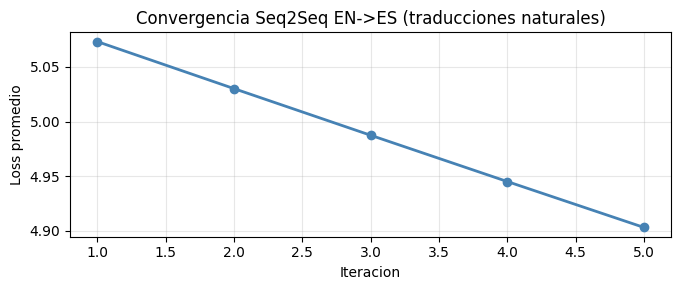

In [22]:
if losses_train:
    plt.figure(figsize=(7,3))
    plt.plot(range(1,6), losses_train, 'o-', color='steelblue', linewidth=2)
    plt.xlabel('Iteracion'); plt.ylabel('Loss promedio')
    plt.title('Convergencia Seq2Seq EN->ES (traducciones naturales)')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig('convergencia_seq2seq.png', dpi=110, bbox_inches='tight')
    plt.show()

---
## Bloque 12: Preguntas de analisis

---

### Pregunta 1 (35 pts)

El corpus tiene tres tipos de pares: traducciones mas cortas en espanol (elision del sujeto: *she sings well* -> *canta bien*), mas largas (perifrasis: *the cat sleeps* -> *el gato esta durmiendo*), y del mismo largo.

a) Durante el entrenamiento con teacher forcing, el decoder para el par (*she sings well*, *canta bien*) corre 2 pasos y para (*the cat sleeps*, *el gato esta durmiendo*) corre 4 pasos. Explique como afecta esa diferencia al gradiente que llega a los pesos del encoder en cada caso. Use la formula del recorrido del gradiente $S + T$ pasos.

b) Durante la inferencia greedy, el decoder debe aprender a generar EOS en el momento correcto. Para un par donde el espanol es mas corto que el ingles, ¿que debe haber aprendido el modelo para detener la generacion antes de que el decoder produzca tantos tokens como el encoder proceso? ¿Que informacion del encoder codifica esa senal de parada?

c) Si ordenara el corpus de entrenamiento de menor a mayor largo de la secuencia de salida (curriculum learning), ¿esperaria que el modelo convergiera mas rapido, mas lento, o igual? Justifique en terminos del gradiente y del proceso de aprendizaje.

**Su respuesta a la Pregunta 1:**

a) Con teacher forcing, el gradiente tiene que viajar desde la pérdida hasta los pesos del encoder recorriendo $S + T$ pasos en total: primero retrocede por los $S$ pasos del decoder y luego por los $T$ pasos del encoder.

Para she sings well → canta bien: $S=2$ pasos decoder + $T=3$ pasos encoder = 5 pasos totales. Para the cat sleeps → el gato está durmiendo: $S=4$ pasos decoder + $T=3$ pasos encoder = 7 pasos totales.

En cada paso el gradiente se multiplica por matrices de pesos, lo que hace que se atenúe. Entonces para el par más largo, el gradiente que llega a los pesos del encoder es más débil (más "diluido") que para el par más corto. Esto significa que el encoder recibe señales de actualización más fuertes cuando el decoder corre pocos pasos y más débiles cuando corre muchos.

b) El modelo necesita aprender a asociar el vector de contexto $h_T^{enc}$ con una señal de "ya terminé". Como el encoder procesa toda la oración en inglés y condensa esa info en $h_T^{enc}$, ese vector tiene que codificar implícitamente la "longitud esperada" de la traducción.

Para pares donde el español es más corto, el modelo aprende durante el entrenamiento que cuando recibe ese tipo de contexto (por ejemplo, oraciones con sujeto elidible), el EOS debe aparecer antes. En la práctica, el output gate del LSTM del decoder aprende a "apagarse" y proyectar hacia EOS cuando ya procesó suficiente información del contexto, sin importar cuántos pasos procesó el encoder.

c) Esperaría que el modelo convergiera más rápido con curriculum learning.

Empezar con secuencias cortas ayuda porque el camino que recorre el gradiente es más corto ($S + T$ pequeño), así que las señales de aprendizaje llegan más claras y fuertes al encoder. El modelo aprende primero los patrones más simples (cómo generar EOS pronto, cómo mapear vocabulario básico) y cuando llegan las secuencias largas, ya tiene una base sólida. Si entrena con secuencias largas desde el inicio, los gradientes son más débiles desde el principio y el modelo tarda más en encontrar una dirección de descenso útil.

---
### Pregunta 2 (35 pts)

a) En el Bloque 10 evalua el porcentaje de oraciones donde la primera palabra generada es correcta. Explique por que esa metrica es mas informativa que la loss de entrenamiento para evaluar la calidad de un sistema de traduccion, y cuales son sus limitaciones.

b) El Bloque 7 muestra que solo una fraccion de las columnas de `E_enc` tienen gradiente no cero en cada actualizacion. Con 78 pares de entrenamiento y 158 palabras en el vocabulario ingles, estime cuantas palabras del vocabulario podrian nunca recibir gradiente durante 5 iteraciones, y que implicacion tiene eso para la representacion de esas palabras.

c) Si quisiera extender este modelo para traducir del espanol al ingles ademas de del ingles al espanol (un solo modelo bidireccional), describa dos enfoques arquitectonicos distintos y justifique cual de los dos preserva mejor la informacion aprendida en este laboratorio.

**Su respuesta a la Pregunta 2:**

a) La métrica de "primera palabra correcta" es más informativa que la loss de entrenamiento porque mide directamente la capacidad del modelo para generar traducciones correctas en lugar de solo optimizar una función matemática. La loss puede disminuir debido a que el modelo se vuelve más confiado en predicciones incorrectas, mientras que esta métrica verifica si el modelo realmente aprendió a traducir.

Sin embargo, tiene limitaciones importantes:
- Solo evalúa la primera palabra, ignorando si el resto de la traducción es correcta
- No captura si la traducción es naturalmente fluida o gramaticalmente correcta
- No mide si el largo de la secuencia generada es apropiado (el modelo podría generar la primera palabra correcta pero luego producir una secuencia muy corta o muy larga)
- No considera sinónimos válidos (una traducción alternativa correcta sería marcada como incorrecta)

Una métrica más completa sería BLEU score que evalúa n-gramas en toda la secuencia.

b) En el corpus de entrenamiento con 78 pares, si contamos los tokens únicos en inglés que aparecen, probablemente hay entre 100-120 palabras distintas utilizadas (considerando repeticiones de palabras comunes como "i", "the", "a"). Con 158 palabras en el vocabulario total, esto significa que aproximadamente 40-60 palabras nunca aparecen en el corpus de entrenamiento.

Durante 5 iteraciones, estas palabras que nunca aparecen en el corpus seguirán sin recibir gradiente, por lo que sus embeddings permanecerán en sus valores iniciales aleatorios. Esto tiene dos implicaciones importantes:

1. **Embeddings no entrenados**: Estas palabras tendrán representaciones que no están alineadas con el espacio semántico aprendido por el resto del vocabulario
2. **Problemas en inferencia**: Si durante la inferencia aparece una oración con estas palabras no vistas, el modelo las procesará con embeddings aleatorios, produciendo traducciones de muy baja calidad

Esto es el problema clásico de "palabras fuera de vocabulario" y justifica el uso del token `<UNK>` para palabras desconocidas.

c) **Enfoque 1: Compartir encoder/decoder con token de dirección**
- Usar un solo encoder y un solo decoder
- Agregar un token especial al inicio de la secuencia que indique la dirección de traducción: `<EN2ES>` o `<ES2EN>`
- Compartir las mismas matrices de embeddings para ambos idiomas (vocabulario conjunto)

**Enfoque 2: Dos pares encoder-decoder independientes con parámetros separados**
- Mantener `E_enc_EN`, `LSTM_enc_EN` para inglés → español
- Crear nuevo `E_enc_ES`, `LSTM_enc_ES` para español → inglés  
- Cada dirección tiene su propio encoder pero podrían compartir el decoder si usan el mismo vocabulario objetivo

**Mejor opción: Enfoque 1**

Consideramos que este enfoque preserva mejor la información aprendida porque:
1. Las representaciones de las palabras en ambos idiomas comparten el mismo espacio de embeddings, lo que permite transferencia de conocimiento semántico entre idiomas
2. El encoder y decoder ya entrenados pueden reutilizarse, solo necesitan aprender a responder al token de dirección
3. Es más eficiente en parámetros y aprovecha mejor los datos existentes (las traducciones EN→ES también informan sobre las relaciones ES→EN)
4. El contexto aprendido del encoder ya captura patrones bilingües que son útiles en ambas direcciones

El Enfoque 2 requeriría entrenar desde cero los nuevos componentes y no aprovecharía el conocimiento ya adquirido sobre las relaciones entre ambos idiomas.

---
### Pregunta 3 (30 pts)

a) Si convirtiera este seq2seq en un autoencoder para comprimir oraciones en espanol, describa exactamente los tres cambios de codigo necesarios en el Bloque 9. Sea especifico sobre la funcion de perdida, los tokens de entrada y salida del decoder, y los vocabularios.

b) En el seq2seq, el backward fluye desde la perdida hasta `E_enc` a traves de $S + T$ pasos. En un autoencoder sobre el mismo corpus, ¿ese recorrido seria el mismo, mas corto o mas largo? Justifique considerando que las oraciones de entrada y salida son iguales.

c) El vector de contexto $\mathbf{c}$ de dimension 32 debe comprimir toda la informacion de la entrada. Para las oraciones mas largas del corpus (*nosotros nos reunimos cada semana*, 5 palabras), ¿es suficiente esa dimension? ¿Que pasaria con la calidad de la reconstruccion si redujera la dimension a 2?

**Su respuesta a la Pregunta 3:**

a) Los tres cambios en el Bloque 9 son:

**1. Un solo vocabulario (el de espanol) para encoder y decoder.** Hoy el encoder usa `tokenize_src` sobre `src_vocab` (158 palabras en ingles) y el decoder usa `tokenize_tgt` sobre `tgt_vocab` (163 en espanol). En el autoencoder la entrada y la salida son la misma oracion en espanol, asi que ambos lados usan `tgt_vocab`: `E_enc_tr` pasa de `(d_emb, src_V)` a `(d_emb, tgt_V)`, y las dos matrices de embedding pueden incluso compartirse (`E_enc_tr = E_dec_tr`), en cuyo caso sus gradientes se suman antes de la actualizacion.

**2. Los datos dejan de ser pares: la fuente y el objetivo son la misma oracion.** En el loop, en lugar de

```python
src_idx  = tokenize_src(src_sent)      # ingles
tgt_full = tokenize_tgt(tgt_sent)      # espanol
```

se usa

```python
tgt_full = tokenize_tgt(tgt_sent)      # espanol
src_idx  = tgt_full[1:-1]              # la MISMA oracion, sin SOS ni EOS, entra al encoder
dec_in   = tgt_full[:-1]               # [SOS, w1, ..., w_n-1]
dec_tgt  = tgt_full[1:]                # [w1, ..., w_n, EOS]
```

El decoder sigue con teacher forcing y sigue arrancando en `<SOS>` y terminando en `<EOS>`: lo unico que cambia es que ahora reconstruye su propia entrada.

**3. La funcion de perdida es la misma entropia cruzada categorica, pero cambia su interpretacion.** `compute_loss` no se modifica: sigue siendo el promedio de $-\log \hat{y}_s[w_s^*]$ sobre los $S$ pasos. Lo que cambia es que $w_s^*$ ya no es la traduccion sino el token original de la entrada, asi que la perdida mide **error de reconstruccion** y no error de traduccion. No hace falta un MSE: la salida sigue siendo una distribucion sobre un vocabulario discreto, no un vector continuo.

Todo lo demas (celda LSTM, backward, SGD) queda intacto: la arquitectura no cambia, solo cambian los datos y los vocabularios.

b) El recorrido seria **mas largo en promedio**, aunque la formula $S + T$ sigue siendo la misma.

En el seq2seq actual el corpus es asimetrico: 57 de 78 pares tienen el espanol *mas corto* que el ingles (diferencia $-1$). Con la entrada en ingles de largo $n$, el promedio es $T = n$ y $S \approx n - 1 + 1 = n$ contando EOS.

En el autoencoder sobre las oraciones en espanol, la entrada y la salida tienen exactamente el mismo largo $n_{es}$: el encoder corre $T = n_{es}$ pasos y el decoder corre $S = n_{es} + 1$ pasos (los $n_{es}$ tokens mas EOS). El recorrido es entonces $2 n_{es} + 1$, siempre simetrico y sin la reduccion que aportaban los pares con elision del sujeto.

Consecuencia practica: el gradiente que llega a `E_enc` atraviesa mas multiplicaciones por las matrices de puertas, por lo que se atenua mas y el encoder aprende mas lento. A cambio, la tarea es mas facil (copiar en vez de traducir), asi que la perdida baja mas rapido pese al recorrido mas largo.

c) Con $d_{hid} = 32$ **si es suficiente para este corpus**. La oracion mas larga es *nos reunimos cada semana* (4 palabras; con el `nosotros` explicito serian 5). El vector de contexto tiene 32 numeros en punto flotante y debe distinguir entre 78 oraciones de a lo sumo 5 tokens sobre un vocabulario de 163 palabras. Como referencia, cada embedding ya usa 16 dimensiones por palabra: 32 dimensiones alcanzan comodamente para codificar identidad de palabras, orden y largo de una secuencia tan corta. El limite real de este laboratorio no es la capacidad del contexto sino el numero de iteraciones (5) y el learning rate (0.01).

Con $d_{hid} = 2$ la reconstruccion colapsaria. Con dos numeros el modelo no puede representar simultaneamente *que* palabras aparecieron, *en que orden* y *cuantas* eran, asi que se ve forzado a quedarse con las direcciones de mayor varianza del corpus. El comportamiento esperado seria:

- El decoder genera la oracion "promedio" o las palabras mas frecuentes del corpus (`el`, `la`, `esta`) sin importar la entrada.
- Oraciones distintas mapean a contextos casi identicos, de modo que sus reconstrucciones se vuelven indistinguibles.
- El control del largo se pierde primero: EOS se emite en un momento arbitrario, y suele aparecer temprano porque es el token que mas reduce la perdida promedio.
- La perdida de entrenamiento baja hasta un piso alto y se estanca: es un cuello de botella de capacidad, no de optimizacion, asi que entrenar mas iteraciones no lo arregla.

Ese es justamente el compromiso de un autoencoder: un cuello de botella pequeno comprime mas pero pierde informacion, y aqui 2 dimensiones estan muy por debajo de lo necesario para reconstruir la secuencia token por token.

---
## Bloque 13: Nota automatica sobre la seccion de codigo

In [23]:
_PUNTOS = {
    'b2': ('Bloque 2:  Encoder forward',           18),
    'b4': ('Bloque 4:  Perdida CE categorica',       8),
    'b5': ('Bloque 5:  Backward decoder',           14),
    'b6': ('Bloque 6:  Backward encoder',           10),
    'b7': ('Bloque 7:  dE completa vs diccionario',  5),
    'b8': ('Bloque 8:  Actualizacion de pesos',      2),
    'b9': ('Bloque 9:  Convergencia 5 iteraciones',  3),
}
_TOTAL = 60
print('=' * 62)
print('  NOTA AUTOMATICA - SECCION DE CODIGO')
print('=' * 62)
_obtenido = 0
for key, (nombre, pts_max) in _PUNTOS.items():
    val = _resultados.get(key, False)
    pts = pts_max if val is True else 0
    _obtenido += pts
    print(f'  {"CORRECTO" if val is True else "PENDIENTE":10s} | {nombre:38s} | {pts:2d}/{pts_max} pts')
if isinstance(_resultados.get('b10'), float):
    print(f'  INFO       | B10 primera palabra test: {_resultados["b10"]:.1f}%')
print('-' * 62)
print(f'  Subtotal codigo:   {_obtenido}/{_TOTAL} puntos')
print('  Pendiente manual:')
print('    Bloque 12 preguntas : __/25 pts')
print('    Comentarios codigo  : __/15 pts')
print('-' * 62)
print('  TOTAL FINAL (sobre 100): __/100 pts')
print('=' * 62)

  NOTA AUTOMATICA - SECCION DE CODIGO
  CORRECTO   | Bloque 2:  Encoder forward             | 18/18 pts
  CORRECTO   | Bloque 4:  Perdida CE categorica       |  8/8 pts
  CORRECTO   | Bloque 5:  Backward decoder            | 14/14 pts
  CORRECTO   | Bloque 6:  Backward encoder            | 10/10 pts
  CORRECTO   | Bloque 7:  dE completa vs diccionario  |  5/5 pts
  CORRECTO   | Bloque 8:  Actualizacion de pesos      |  2/2 pts
  CORRECTO   | Bloque 9:  Convergencia 5 iteraciones  |  3/3 pts
  INFO       | B10 primera palabra test: 0.0%
--------------------------------------------------------------
  Subtotal codigo:   60/60 puntos
  Pendiente manual:
    Bloque 12 preguntas : __/25 pts
    Comentarios codigo  : __/15 pts
--------------------------------------------------------------
  TOTAL FINAL (sobre 100): __/100 pts
